# SST Satellites and Data Products

## SST Satellites

SST observations began with the Advanced Very High Resolution Radiometer in 1981 and have continued uninterrupted until present day. The satellites with sensors designed for observing sea surface temperature are outlined in the following diagram and described below.

```{figure} ../images/sst/timeline_sst.png
---
height: 400px
name: timeline-sst
---
```

## Common Satellite Sensors for SST

### AVHRR

The Advanced Very High Resolution Radiometer (AVHRR) has provided SST observations from NOAA weather satellites since the early 1980s. It was used on the "NOAA-N" satellite from 7 through 18. Its long record makes it especially valuable for multi-decadal SST analyses. The "very high" resolution of the AVHRR sensor is approximately 1 kilometer.

```{figure} ../images/sst/noaa18.jpg
---
height: 400px
name: noaa-18
---
```

The image above shows an artist rendition of the NOAA-18 satellite, one of the many NOAA weather satellite that have been equipped with the AVHRR sensor.

### VIIRS

The Visible Infrared Imaging Radiometer Suite (VIIRS) is a modern sensor flown first on Suomi NPP and later NOAA polar-orbiting satellites. This is the same sensor introduced in the [ocean color](../ocean-color-satellites-and-data#viirs) section when discussing chlorophyll-a estimates. VIIRS continues the operational visible and infrared imaging record.

### TIRS

The Thermal Infrared Sensor (TIRS) provides higher spatial resolution thermal infrared observations than many global SST sensors. This can be useful for coastal and nearshore temperature patterns, although revisit time, clouds, and atmospheric correction remain important limitations. The TIRS sensor was first deployed on the [Landsat 8](../landsat-program#landsat-8-9) in 2013 and was launched again on Landat 9.

### MODIS

The Moderate Resolution Imaging Spectroradiometer (MODIS) on the Terra and Aqua satellites (also introduced in the ([ocean color](../ocean-color-satellites-and-data#modis) section). MODIS has 16 bands in the thermal infrared and has been widely used for SST applications.

### ATSR and AATSR

The Along Track Scanning Radiometer (ATSR) instrument flew on the European satellites ERS-1 and ERS-2. collected thermal infrared observations useful for SST retrievals and climate records. The following image shows an artist rendition of ERS-1:

```{figure} ../images/sst/ers1.jpg
---
height: 400px
name: ers-1
---
```

ATSR collected IR measurements in the same bands at AVHRR. Later, the Advanced ATSR (AATSR) offered an improvement on over ATSR and was flown on the European Envisat satellite.

## SST Products

There are a wide range of SST products derived from thermal infrared observations. The easiest to use are the [Level 3](../fundamentals/data_product_levels.ipynb) gridded products and the [Level 4](../fundamentals/data_product_levels.ipynb) multi-mission optimally-interpolated products. Let's take a look at a few examples below.

First, let's read in a few Python modules:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import cmocean.cm as cm

### Level 3 SST Products

Just as for the examples shown for ocean color, the Level 3 MODIS SST data is easy to find and download from the [NASA Ocean Color OB.DAAC](https://oceancolor.gsfc.nasa.gov/l3/). Let's plot an example:

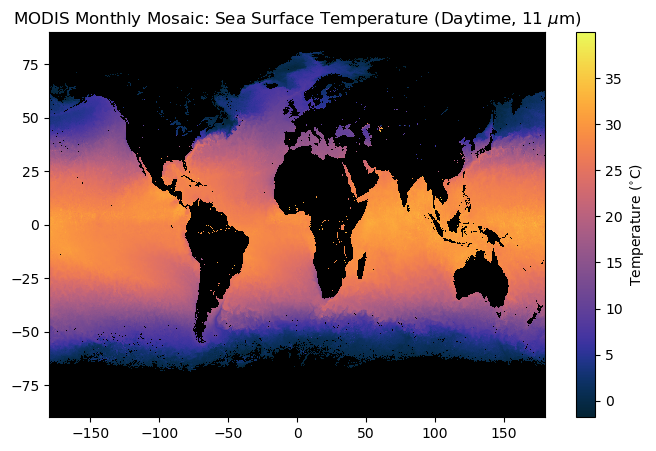

In [5]:
# https://oceandata.sci.gsfc.nasa.gov/cgi/getfile/AQUA_MODIS.20150401_20150430.L3m.MO.SST.sst.4km.nc
file_name = '../data/sst/AQUA_MODIS.20150401_20150430.L3m.MO.SST.sst.4km.nc'

# read in the file
ds = nc4.Dataset(file_name)
lon = ds.variables['lon'][:]
lat = ds.variables['lat'][:]
chlor_a = ds.variables['sst'][:,:]
ds.close()

# plot the figure
plt.figure(figsize=(8,5))
plt.gca().set_facecolor('black')
pm = plt.pcolormesh(lon, lat, chlor_a, cmap=cm.thermal)
plt.title('MODIS Monthly Mosaic: Sea Surface Temperature (Daytime, 11 $\\mu$m)')
cb = plt.colorbar(pm)
cb.set_label('Temperature ($^{\\circ}$C)')
plt.show()

In this plot, we see evidence of lots of oceanographic processes including eddies in the Southern Ocean and around active boundary currents such as the Gulf Stream.

### Level 4 SST Products

Level 4 SST prducts can offer some additional insights over Level 3 products because optimal interpolation approaches have been used to fill gaps in data that arise due to clouds or other obstructions between the ocean surface and the satellite. As with all interpolated products, gap-filled values should be interpreted with **optimistic caution**: they are useful and often necessary, but they are not the same as direct observations.

### MUR SST

The [Multi-scale Ultra-high Resolution](https://podaac.jpl.nasa.gov/MEaSUREs-MUR) SST product is a merged and interpolated product that combines available SST observations. It is designed to capture realistic SST variability while filling gaps caused by clouds or missing observations. As of present writing, it has been processed from 2002 (corresponding with Aqua-MODIS) through 2024. For more information on this product, see [Chin et al. 2017](https://doi.org/10.1016/j.rse.2017.07.029).

### SST CCI

The [Sea Surface Temperature Climate Change Initiative](https://climate.esa.int/en/projects/sea-surface-temperature/) is an ESA project focused on producing longer, more stable, and more accurate SST products for climate applications. Like MUR and other Level 4 products, lower-level retrievals are combined and interpolated to produce spatially complete fields. As of present writing, it has been processed from 1981 (corresponding with AVHRR) through 2016. For more information on this product, see [Embury et al. 2024](https://doi.org/10.1038/s41597-024-03147-w).